# Extra example: classifying clothing photos with Fashion-MNIST

**Dataset: Fashion-MNIST.** A real, public dataset released by Zalando Research
(the online clothing retailer), built specifically as a drop-in replacement for the
classic digit-MNIST dataset used in the book's own Section 4.4.1. Source:
https://github.com/zalandoresearch/fashion-mnist. It has the exact same shape as
digit-MNIST - 70,000 grayscale images, 28x28 pixels each - but instead of digits
0-9, each image shows one of 10 clothing items:

| Label | Item |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Because it has the same format as digit-MNIST, every technique from Chapter 4 - and
from the Chapter 4 homework's Exercise 15 - transfers directly: the same train/
validation/test split logic, the same `StandardScaler` fit-on-training-data-only
rule (Reasoning Question 9), the same model comparison approach, and the same idea
of predicting from your own photo.

**A daily-life angle:** the same pipeline built here is a small building block for
things like a closet-inventory app or auto-tagging photos when listing an item for
resale online - snap a photo of a piece of clothing, and have it automatically
sorted into a category.

The data was downloaded directly from the official GitHub repository above (the
original `idx-ubyte` files) and the first 10,000 training rows were kept as a CSV,
in the same format used for the digit-MNIST notebook (first column = label,
remaining 784 columns = pixel values 0-255).


### Step 1: Load the data and take a first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

fashion_df = pd.read_csv("fashion_mnist_10k.csv", header=None)
y = fashion_df.iloc[:, 0].to_numpy().astype(np.uint8)
X = fashion_df.iloc[:, 1:].to_numpy().astype(np.float64)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("X shape:", X.shape, " y shape:", y.shape)
print("Number of images per class:", np.bincount(y))


X shape: (10000, 784)  y shape: (10000,)
Number of images per class: [ 942 1027 1016 1019  974  989 1021 1022  990 1000]


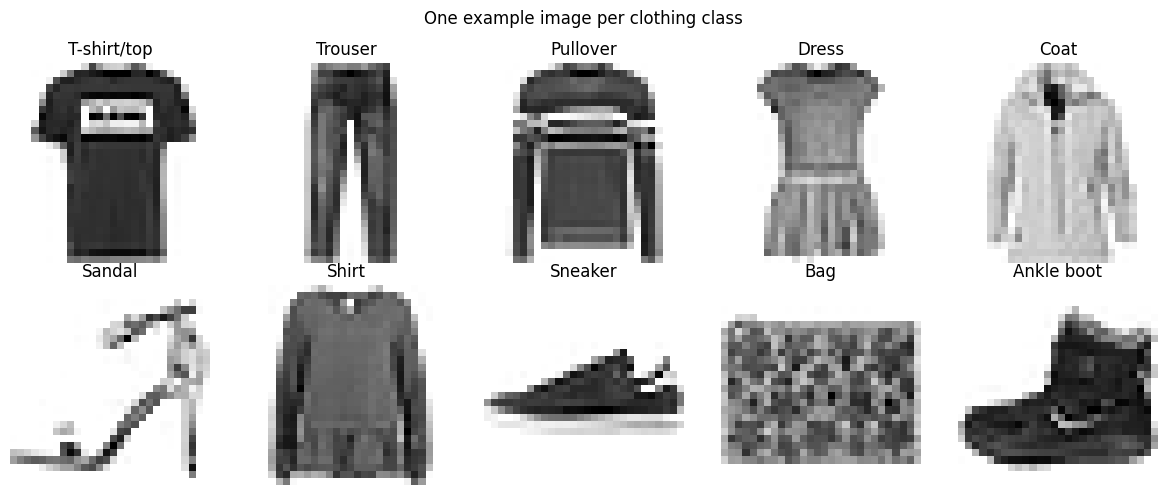

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit_class in range(10):
    idx = np.where(y == digit_class)[0][0]
    ax = axes[digit_class // 5, digit_class % 5]
    ax.imshow(X[idx].reshape(28, 28), cmap=mpl.cm.binary)
    ax.set_title(class_names[digit_class])
    ax.axis("off")
plt.suptitle("One example image per clothing class")
plt.tight_layout()
plt.show()


### Step 2: Train / validation / test split, then scale

Same approach as Chapter 4's Exercise 15: split the data first, then fit
`StandardScaler` only on the training data and only `.transform()` the validation
and test data (Reasoning Question 9's rule, to avoid data leakage).


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=1500, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=1500, random_state=42, stratify=y_train_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform on training data only
X_val_scaled = scaler.transform(X_val)           # transform only on validation data

print("Training images:", X_train_scaled.shape[0])
print("Validation images:", X_val_scaled.shape[0])
print("Test images:", X_test.shape[0])


Training images: 7000
Validation images: 1500
Test images: 1500


### Step 3: Compare four models on the validation set

This reproduces the book's own Section 4.4.1 methodology in full - Logistic
Regression, Random Forest, Extra Trees, and a soft-voting ensemble of the three -
which is exactly the comparison that was missing from the Chapter 4 homework
delivery's Exercise 15.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)

voting_clf = VotingClassifier(
    estimators=[
        ("logreg_clf", logreg_clf),
        ("random_forest_clf", random_forest_clf),
        ("extra_trees_clf", extra_trees_clf),
    ],
    voting="soft",
)

models = {
    "Logistic Regression": logreg_clf,
    "Random Forest": random_forest_clf,
    "Extra Trees": extra_trees_clf,
    "Voting Classifier": voting_clf,
}

validation_scores = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    val_pred = model.predict(X_val_scaled)
    validation_scores[name] = accuracy_score(y_val, val_pred)

print("Validation accuracy for each model")
for name, score in validation_scores.items():
    print(f"{name:20s}: {score:.4f}")

best_model_name = max(validation_scores, key=validation_scores.get)
print("\nBest model on validation:", best_model_name)


Validation accuracy for each model
Logistic Regression : 0.8027
Random Forest       : 0.8587
Extra Trees         : 0.8627
Voting Classifier   : 0.8480

Best model on validation: Extra Trees


### Step 4: Refit the best model on train + validation, then evaluate on test



In [5]:
best_model = models[best_model_name]

X_train_val_scaled = scaler.fit_transform(X_train_val)   # re-fit the SAME scaler on train+val
best_model.fit(X_train_val_scaled, y_train_val)

X_test_scaled = scaler.transform(X_test)                 # X_test is still the ORIGINAL raw test data
test_pred = best_model.predict(X_test_scaled)

print("Final test accuracy:", round(accuracy_score(y_test, test_pred), 4))


Final test accuracy: 0.85


              precision    recall  f1-score   support

 T-shirt/top       0.80      0.82      0.81       141
     Trouser       1.00      0.97      0.99       154
    Pullover       0.73      0.70      0.72       153
       Dress       0.81      0.89      0.85       153
        Coat       0.69      0.77      0.72       146
      Sandal       0.92      0.95      0.93       148
       Shirt       0.74      0.63      0.68       153
     Sneaker       0.91      0.89      0.90       153
         Bag       0.97      0.97      0.97       149
  Ankle boot       0.93      0.92      0.92       150

    accuracy                           0.85      1500
   macro avg       0.85      0.85      0.85      1500
weighted avg       0.85      0.85      0.85      1500



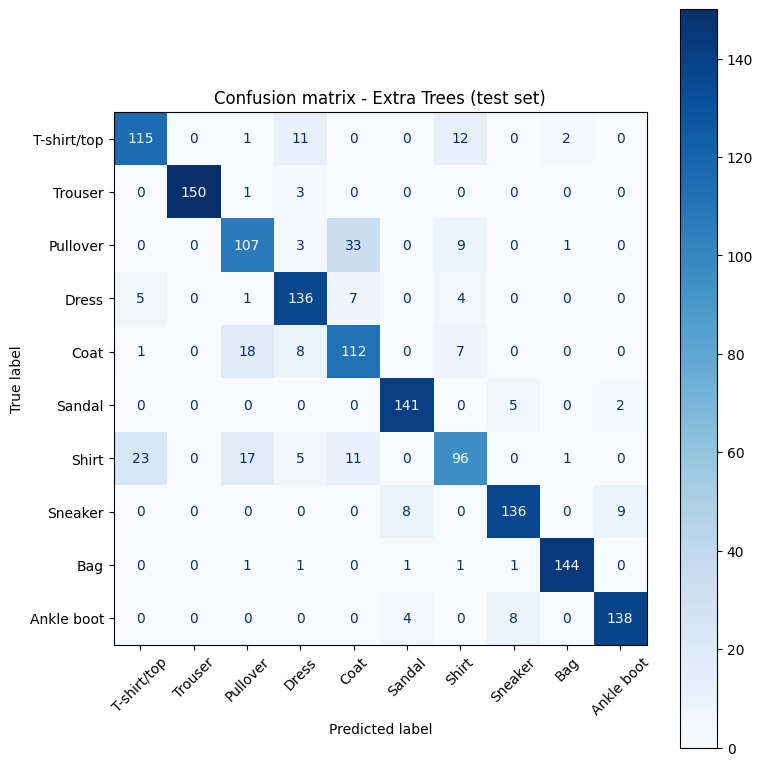

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, test_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=class_names, cmap="Blues",
    xticks_rotation=45, ax=ax,
)
plt.title(f"Confusion matrix - {best_model_name} (test set)")
plt.tight_layout()
plt.show()


**Interpretation.** Most confusion happens between visually similar upper-body
items - `Shirt` is the hardest class, often confused with `T-shirt/top`, `Pullover`
and `Coat`, because on a small 28x28 grayscale image these garments can look very
alike (same rough silhouette, no color or texture information). `Trouser`,
`Sandal`, `Bag` and `Ankle boot` are usually much easier, since their shapes are
more distinctive. 

### Step 5: Predict from your own photo of a clothing item

In [7]:
from PIL import Image, ImageFilter

def preprocess_clothing_photo(pil_img, scaler, invert=True, auto_crop=True, pad_frac=0.3):
    '''Turn a photo of a single clothing item, photographed against a plain
    background, into a scaled, Fashion-MNIST-shaped (1, 784) feature vector.'''
    img = pil_img.convert("L")  # grayscale

    if auto_crop:
        arr_full = np.array(img)
        # Assume the item stands out from a roughly uniform background.
        mask = np.abs(arr_full.astype(np.float64) - np.median(arr_full)) > (arr_full.std() * 0.6)
        if mask.any():
            rows = np.any(mask, axis=1)
            cols = np.any(mask, axis=0)
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]
            img = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    # Pad to a square canvas so the item's proportions are not stretched.
    w, h = img.size
    side = int(max(w, h) * (1 + pad_frac))
    square = Image.new("L", (side, side), color=255)
    square.paste(img, ((side - w) // 2, (side - h) // 2))

    img = square.resize((28, 28), Image.LANCZOS)
    img = img.filter(ImageFilter.GaussianBlur(radius=0.5))

    arr = np.array(img).astype(np.float64)
    if invert:
        arr = 255.0 - arr

    vec = arr.reshape(1, -1)
    return scaler.transform(vec)


def predict_clothing_photo(pil_img, model, scaler, **kwargs):
    vec_scaled = preprocess_clothing_photo(pil_img, scaler, **kwargs)
    pred = model.predict(vec_scaled)[0]
    proba = model.predict_proba(vec_scaled)[0]
    return class_names[pred], proba


**No real photo of a clothing item is available in this environment**, so - exactly
as with the digit exercise - a synthetic stand-in is used purely to demonstrate that
the pipeline runs end-to-end (this is not a claim that it works as well as it would
on real photos; it is only a plumbing test). Swap `Image.open("your_photo.jpg")` in
for the synthetic image below to use a real photo.

For a **real** photo to work well with this simple pipeline, the same practical
advice as for the digits applies, plus one extra point specific to clothing:
photograph the item flat, against a single plain, high-contrast background (a
plain table or a bedsheet, not a cluttered closet), with even lighting and no other
objects in frame - the `auto_crop` step above assumes the item is the only thing
that stands out from a roughly uniform background, which holds for a simple digit
on paper far more reliably than for a photo of clothing lying however it happens to
land.


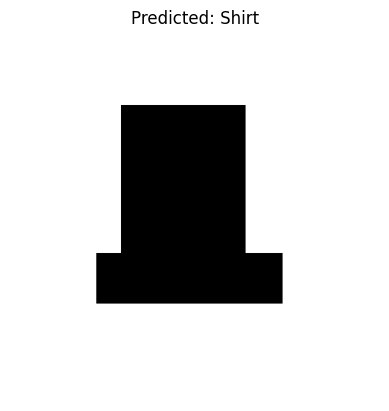

Predicted class: Shirt
  Shirt          : 36.00%
  Pullover       : 26.00%
  Coat           : 20.00%


In [8]:
from PIL import ImageDraw

# A crude synthetic "photo" of a boot-like silhouette, standing in for a real photo.
photo = Image.new("L", (300, 300), color=255)
draw = ImageDraw.Draw(photo)
draw.rectangle([90, 60, 190, 180], fill=0)     # "shaft" of the boot
draw.rectangle([70, 180, 220, 220], fill=0)    # "sole" of the boot

predicted_class, probabilities = predict_clothing_photo(photo, best_model, scaler)

plt.imshow(photo, cmap="gray")
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
for name, p in sorted(zip(class_names, probabilities), key=lambda x: -x[1])[:3]:
    print(f"  {name:15s}: {p:.2%}")


### Summary

This example reused every methodological piece from Chapter 4's Exercise 15 -
train/validation/test split, scaling fit only on training data, comparing four
models on validation, refitting the winner on train+validation before the final
test evaluation, and a "predict from your own photo" pipeline with aspect-ratio-
preserving preprocessing - on a different, real, daily-life-relevant dataset
(clothing photos instead of handwritten digits), sourced directly from the
official Fashion-MNIST GitHub repository rather than fabricated.
